# Week 03: Dimensionality Reduction and Similarities

## Text as Data

Professor: Elliott Ash, NYU

TA: Eduardo Zago, NYU

More accurate objective of the course: learning how to use text as data for research objectives, while also trying to understand how to build an LLM from scratch.

What have we done so far:

1.   Introduction to tools to manage text in Python
2.   Preprocessing of text
3.   Tokenization of text (encoder-decoder algorithms)

Now, how do we represent this tokens mathematically? And what can we do with this representations?

In [3]:
# set random seed
import numpy as np
import warnings
warnings.simplefilter("ignore", DeprecationWarning)
import warnings; warnings.simplefilter('ignore')
%matplotlib inline
import pandas as pd
import re
import matplotlib.pyplot as plt
from string import punctuation

!pip install gensim

import spacy
nlp = spacy.load('en_core_web_sm')

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk import sent_tokenize

!pip install pyLDAvis

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

In [4]:
df = pd.read_pickle('sc_cases_cleaned.pkl',
                    compression = 'gzip')

# Basic preprocessing for the dataset
translator = str.maketrans(' ', ' ', punctuation)
from nltk.tokenize import word_tokenize

def preprocess(doc):
  doc = doc.replace('\r', ' ').replace('\n', ' ')
  doc = re.sub(r"(\d)([A-Za-z])", r"\1 \2", doc) # separate numbers from strings
  doc = re.sub(r"([A-Za-z])(\d)", r"\1 \2", doc) # separate strings from numbers
  d = doc.translate(translator).lower() # remove punctuation
  words = word_tokenize(d)
  words = [w for w in words if w not in stoplist] # remove stopwords
  words = [w if not w.isdigit() else '#' for w in words] # normalize numbers
  output = ' '.join(words) # Let's not tokenize now
  return output

Last lab we introduced how one would represent mathemathically a corpus: term document matrix X, where

1. rows = documents
2. columns = tokens (words or n-grams)
3. values = counts

In [5]:
preprocessed_opinion = list(map(preprocess, df['opinion_text'])) # Note list()

# Generate a date - judge index
df['index'] = df['authorship'] + df['date_standard'].astype(str)

from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(min_df=0.01,
                      max_df=.9,
                      max_features=1000)

X = vec.fit_transform(preprocessed_opinion)

vocab_opinions = vec.get_feature_names_out()
X_lab = pd.DataFrame(X.toarray(), columns=vocab_opinions, index=df['index']) # only for didactic purposes, keep only the X

X_lab

,ability,absence,absent,abuse,accept,access,according,accordingly,account,act,...,witnesses,word,words,work,writ,written,year,years,yet,york
index,,,,,,,,,,,,,,,,,,,,,
GINSBURG2003-03-04,0,1,0,0,0,0,0,0,0,6,...,0,0,7,0,5,1,3,0,0,0
STEVENS2003-06-09,0,1,0,0,0,0,0,0,0,11,...,0,0,1,0,0,0,0,0,1,0
O'CONNOR2005-03-30,1,0,1,3,0,0,0,1,0,1,...,0,0,0,0,4,0,0,1,0,0
KENNEDY2005-06-06,1,0,0,0,4,0,3,0,0,20,...,0,1,0,0,0,6,0,4,2,0
KENNEDY2005-06-13,0,0,0,0,0,2,2,0,0,1,...,7,1,0,1,0,5,3,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BREYER2001-04-18,0,0,1,0,1,0,0,1,2,0,...,0,0,1,0,0,0,0,0,2,0
SOUTER2001-04-24,0,2,2,3,0,0,2,3,3,18,...,0,0,1,0,0,1,1,6,1,9
SCALIA2001-04-24,0,0,1,0,2,0,1,0,0,12,...,0,0,0,0,1,1,1,2,1,4


Different ways of measuring similarity across text. The first one that comes to mind is the Euclidean distance:

$$\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \\ \dots \\ x_n \end{bmatrix}, \mathbf{y} = \begin{bmatrix} y_1 \\ y_2 \\ \dots \\ y_n \end{bmatrix}$$

$$\|\mathbf{x}-\mathbf{y}\| = \sqrt{\sum_{i=1}^n\left(x_i-y_i\right)^2}$$

In [6]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances #NEW

euclid = euclidean_distances(X_lab) # Computes the pairwise Euclidean distance between all rows. this is

print(euclid[0,2]) # What is this? The Euclidean distance between document 0 and document 2 in the vector space defined by the document-term matrix.

94.12226091632095


### Cosine

$$\cos θ = \frac{\mathbf{x}^{\top}\mathbf{y}}{\|\mathbf{x}\|\|\mathbf{y}\|}$$

In [7]:
cos = cosine_similarity(X_lab)

print(cos[0,2])

0.3766859843876832


Cosine similarity is ubiquitous in NLP because almost everything reduces to comparing vectors, and cosine is a simple, scale-invariant, and empirically effective way to compare vector meaning.

Why cosine?

1) Ignores absolute magnitude

2) Focuses on direction (semantic content)

Let's look at an example:

In [8]:
X_aug = X_lab.copy()
X_aug.loc["last_x4"] = 4 * X_lab.iloc[-1]

# 2) compare similarities/distances
cos = cosine_similarity(X_aug)
euc = euclidean_distances(X_aug)

print("Cosine similarity (last vs 4x-last):", cos[len(X_aug) - 2, len(X_aug) - 1])
print("Euclidean distance (last vs 4x-last):", euc[len(X_aug) - 2, len(X_aug) - 1])

Cosine similarity (last vs 4x-last): 0.9999999999999999
Euclidean distance (last vs 4x-last): 383.8945167620918


### tf-idf (Term Frequency–Inverse Document Frequency)

$$tfidf_{t,d} = tf_{t,d} \times \log\left(\frac{N}{df_t}\right)$$

where

$$tf_{t,d} = \frac{\text{count of } t \text{ in } d}{\sum_{t'} \text{count of } t' \text{ in } d}.$$

$df_t$ is the number of documents containing term
𝑡.

KEY CONCEPT: a word is important if...

1) it appears often in a document (high term frequency),

2) but not often across all documents (low global frequency).

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer # NEW

tfidf = TfidfVectorizer(min_df=0.01,
                        max_df=0.9,
                        max_features=1000)

X = tfidf.fit_transform(preprocessed_opinion)

X_tfidf = pd.DataFrame(X.toarray(), columns=vocab_opinions, index=df['index'])

X_tfidf

,ability,absence,absent,abuse,accept,access,according,accordingly,account,act,...,witnesses,word,words,work,writ,written,year,years,yet,york
index,,,,,,,,,,,,,,,,,,,,,
GINSBURG2003-03-04,0.000000,0.014656,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052987,...,0.000000,0.000000,0.094594,0.000000,0.099100,0.017477,0.044794,0.000000,0.000000,0.000000
STEVENS2003-06-09,0.000000,0.018466,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.122402,...,0.000000,0.000000,0.017027,0.000000,0.000000,0.000000,0.000000,0.000000,0.018435,0.000000
O'CONNOR2005-03-30,0.012637,0.000000,0.012346,0.046809,0.000000,0.000000,0.000000,0.010058,0.000000,0.007053,...,0.000000,0.000000,0.000000,0.000000,0.063316,0.000000,0.000000,0.008771,0.000000,0.000000
KENNEDY2005-06-06,0.003514,0.000000,0.000000,0.000000,0.015008,0.000000,0.008946,0.000000,0.000000,0.039222,...,0.000000,0.003526,0.000000,0.000000,0.000000,0.023286,0.000000,0.009755,0.006498,0.000000
KENNEDY2005-06-13,0.000000,0.000000,0.000000,0.000000,0.000000,0.020515,0.014892,0.000000,0.000000,0.004897,...,0.084525,0.008806,0.000000,0.009173,0.000000,0.048454,0.024838,0.006090,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BREYER2001-04-18,0.000000,0.000000,0.005965,0.000000,0.006519,0.000000,0.000000,0.004859,0.011464,0.000000,...,0.000000,0.000000,0.005214,0.000000,0.000000,0.000000,0.000000,0.000000,0.011291,0.000000
SOUTER2001-04-24,0.000000,0.006127,0.006463,0.012251,0.000000,0.000000,0.005614,0.007897,0.009315,0.033227,...,0.000000,0.000000,0.002825,0.000000,0.000000,0.003653,0.003121,0.013774,0.003058,0.032483
SCALIA2001-04-24,0.000000,0.000000,0.008075,0.000000,0.017652,0.000000,0.007015,0.000000,0.000000,0.055357,...,0.000000,0.000000,0.000000,0.000000,0.010353,0.009129,0.007800,0.011473,0.007643,0.036078


### Co-Ocurrence (term-term matrices)

Like documents, terms can also be represented using counts from a corpus. One popular method is to 'count the neighbors,' which surprisingly captures many properties about the word.

Note: "Co-occurrence matrix" is more often used in NLP, but "term-term matrix" might be more intuitive to think about in relationship to "term-document matrix."


In [11]:
from collections import defaultdict, Counter #NEW

gins = df[df.iloc[:, 3]=='GINSBURG']
preprocess_gins = list(map(preprocess, gins['opinion_text']))

# Restrict to a known vocabulary to keep the matrix manageable
vocab_set = set(vocab_opinions)

# Adapted from https://www.geeksforgeeks.org/co-occurence-matrix-in-nlp/
# Input: list of strings, window size, vocabulary set
def get_ttm(corpus, window_size, vocab=None):
  co_occurrences = defaultdict(Counter)

  for article in corpus:
    words = article.split(" ")
    if vocab is not None:
      words = [w for w in words if w in vocab]
    for i, word in enumerate(words):
        for j in range(max(0, i-window_size), min(len(words), i+window_size+1)):
            if i != j:
                co_occurrences[word][words[j]] += 1

  unique_words = list(vocab) if vocab is not None else list({w for a in corpus for w in a.split()})
  word_index = {word: idx for idx, word in enumerate(unique_words)}
  co_matrix = np.zeros((len(unique_words), len(unique_words)), dtype=np.int32)

  for word, neighbors in co_occurrences.items():
      for neighbor, count in neighbors.items():
          if word in word_index and neighbor in word_index:
              co_matrix[word_index[word]][word_index[neighbor]] = count

  co_matrix_df = pd.DataFrame(co_matrix, index=unique_words, columns=unique_words)
  return co_matrix_df, word_index


# get TTM for Ginsburg opinions, restricted to shared vocab
opinion_ttm_w1, opinion_w2i_w1 = get_ttm(preprocess_gins, 2, vocab_set)


In [12]:
opinion_ttm_w1

,determined,emphasis,pursuant,pay,funds,taxes,approach,definition,exception,since,...,vehicle,plan,charged,employees,argues,text,pp,occurred,include,religious
determined,0,0,1,0,0,0,0,0,1,0,...,0,0,1,1,0,0,1,1,0,0
emphasis,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
pursuant,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
pay,0,0,0,2,2,5,0,0,0,0,...,0,1,0,3,0,0,0,0,0,1
funds,0,0,0,2,0,1,1,0,0,0,...,0,2,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
text,0,0,0,0,0,1,1,3,3,1,...,0,0,0,0,2,4,0,0,0,0
pp,1,1,0,0,0,1,0,0,2,0,...,0,1,0,0,0,0,4,1,0,0
occurred,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
include,0,0,0,0,0,0,0,4,1,0,...,0,5,0,1,0,0,0,0,0,2


In [13]:
# get TTM for all opinions with window size 1, restricted to shared vocab
opinion_ttm_w1, opinion_w2i_w1 = get_ttm(preprocessed_opinion, 1, vocab_set)

# invert dictionary: index -> word
opinion_i2w_w1 = {idx: word for word, idx in opinion_w2i_w1.items()}

# calculate cosine similarity
query_word = "act"  # change to any word in vocab_opinions
people_sim_w1 = cosine_similarity(opinion_ttm_w1)[opinion_w2i_w1[query_word]]
top_sim_locations_w1 = np.argsort(-1*people_sim_w1)  # -1 is for descending order
top10_words_w1 = [opinion_i2w_w1[i] for i in top_sim_locations_w1[:10]]
top10_similarities_w1 = [people_sim_w1[i] for i in top_sim_locations_w1[:10]]
print(top10_words_w1)
print(top10_similarities_w1)


['act', 'amended', 'ch', 'rev', 'amendments', 'usc', 'stat', 'provision', 'section', 'note']
[np.float64(1.0), np.float64(0.7892320255270351), np.float64(0.75434809526125), np.float64(0.6875946208376562), np.float64(0.5970344717067271), np.float64(0.5688677412531722), np.float64(0.5672277145284316), np.float64(0.5246181653270983), np.float64(0.5114887755122411), np.float64(0.4956476709004887)]


Note 2: Representations in co-occurrence matrices become more reliable with more text data (i.e. larger corpora). Because the corpus we're using today is somewhat small, the results from the example below might seem somewhat unintuitive. The main goal should be to get an idea of how to build a co-occurrence matrix and calculate similarity over it.

### Applications:

1.   Clustering (K-Means, DBSCAN, PCA)
2.   Topic Modelling (LDA, Structural Topic Modelling)

#### K-Means

K-means is an unsupervised learning algorithm used to partition data into
𝐾 clusters based on similarity.



In [14]:
from sklearn.cluster import KMeans #NEW

#
num_clusters = 20 # Optimal number of clusters
km = KMeans(n_clusters=num_clusters)
km.fit(X_tfidf)

doc_clusters = km.labels_.tolist()

Several ways of choosing K:

1) Elbow method: look for diminishing returns in within-cluster variance.

2) Silhouette score: choose 𝐾 that maximizes cluster separation.

3) Domain knowledge.

The silhouette score provides a normalized measure of how well observations are clustered, balancing within-cluster similarity and between-cluster separation. Measures if an observation is well contained in its own cluster and away from other clusters.

In K-Means, it is a diagnostic tool rather than an optimization criterion.

In [15]:
from sklearn.metrics import silhouette_score
silhouette_score(X_tfidf, km.labels_)

sil_scores = []
for n in range(2, num_clusters):
    km = KMeans(n_clusters=n)
    km.fit(X_tfidf)
    sil_scores.append(silhouette_score(X_tfidf, km.labels_))

opt_sil_score = max(sil_scores[5:20])
sil_scores.index(opt_sil_score)
opt_num_cluster = range(2, num_clusters)[sil_scores.index(opt_sil_score)]
print('The optimal number of clusters is %s' %opt_num_cluster)


The optimal number of clusters is 19


#### DBSCAN

DBSCAN finds dense clusters and detects outliers without pre-specifying the number of clusters.

In [16]:
from sklearn.cluster import DBSCAN # NEW

dbscan = DBSCAN(eps=0.95, min_samples=5)
dbscan.fit(X_tfidf)
db_clusters = dbscan.labels_

df['cluster_db'] = db_clusters
df[df['cluster_db']==1]['opinion_text']

17     Justice Alito delivered the opinion of the Cou...
122    Justice Ginsburg delivered the opinion of the ...
238    Chief Justice Roberts delivered the opinion of...
291    Justice Alito delivered the opinion of the Cou...
410    Justice Alito delivered the opinion of the Cou...
528    Justice Thomasdelivered the opinion of the Cou...
530    Justice Thomas delivered the opinion of the Co...
685    JUSTICE GINSBURG delivered the opinion of the ...
769    CHIEF JUSTICE REHNQUIST delivered the opinion ...
Name: opinion_text, dtype: object

#### PCA

Everything is SVD: PCA (Principal Component Analysis) is a dimensionality-reduction method that finds the directions of maximum variance in the data.

Computes the SVD of the normalized covariate matrix.

In [17]:
from sklearn.decomposition import PCA # NEW

pca_tfidf = PCA()

pca_tfidf.fit(X_tfidf)

cumvar_tfidf = np.cumsum(pca_tfidf.explained_variance_ratio_)

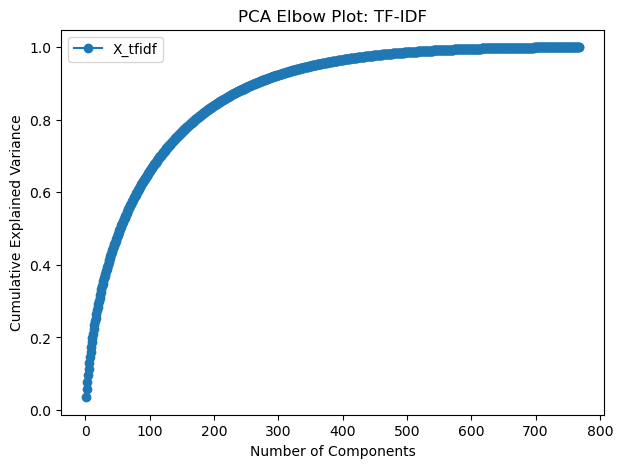

In [18]:
plt.figure(figsize=(7,5))
plt.plot(range(1, len(cumvar_tfidf)+1), cumvar_tfidf, marker='o', label="X_tfidf")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Elbow Plot: TF-IDF")
plt.legend()
plt.show()


Is this a good elbow plot? What is the conclusion that we get from this?

With text data, elbows are often weak or smooth (Why?)

### Topic Modelling

#### LDA (Latent Dirichlet Allocation)

LDA is a probabilistic topic model used to discover latent topics in a collection of documents.

Topics are latent (unobserved) and inferred from word co-occurrence patterns.

In [19]:
# split into paragraphs
doc_clean = []
for doc in preprocessed_opinion:
    # split by paragraph
    for paragraph in doc.split("\n\n"):
        doc_clean.append(doc.split())
print(doc_clean[:2])

[['justice', 'ginsburg', 'delivered', 'opinion', 'court', 'motion', 'federal', 'prisoner', 'postconviction', 'relief', '#', 'usc', '§', '#', 'subject', 'oneyear', 'time', 'limitation', 'generally', 'runs', 'date', 'judgment', 'conviction', 'becomes', 'final', '§', '#', 'p', '#', 'case', 'concerns', 'starting', 'date', 'oneyear', 'limitation', 'presents', 'narrow', 'recurring', 'question', 'courts', 'appeals', 'divided', 'defendant', 'federal', 'prosecution', 'takes', 'unsuccessful', 'direct', 'appeal', 'judgment', 'conviction', 'next', 'petition', 'writ', 'certiorari', 'court', 'judgment', 'become', 'final', 'postconviction', 'relief', 'purposes', '#', 'appellate', 'court', 'issues', 'mandate', 'affirming', 'conviction', 'instead', '#', 'date', 'ordinarily', '#', 'days', 'later', 'time', 'filing', 'petition', 'certiorari', 'expires', 'accord', 'courts', 'consistent', 'understanding', 'finality', 'context', 'collateral', 'review', 'weight', 'lower', 'court', 'authority', 'reject', 'issu

In [20]:
# randomize document order
from random import shuffle
shuffle(doc_clean)

# creating the term dictionary
from gensim import corpora # New
dictionary = corpora.Dictionary(doc_clean)
# filter extremes, drop all words appearing in less than 10 paragraphs and all words appearing in at least every third paragraph
dictionary.filter_extremes(no_below=10, no_above=0.33, keep_n=1000)
print(len(dictionary))

1000


In [21]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow",
    category=DeprecationWarning
)

# creating the document-term matrix
doc_term_matrix = [dictionary.doc2bow(doc) for doc in doc_clean]

# train LDA with 10 topics and print
from gensim.models.ldamodel import LdaModel
lda = LdaModel(doc_term_matrix, num_topics=14,
               id2word = dictionary, passes=3)
lda.show_topics(formatted=True)

[(np.int64(7),
  '0.013*"offense" + 0.012*"crime" + 0.010*"prison" + 0.010*"drug" + 0.009*"commission" + 0.009*"plaintiffs" + 0.009*"plaintiff" + 0.006*"imprisonment" + 0.006*"subsection" + 0.006*"california"'),
 (np.int64(2),
  '0.028*"death" + 0.022*"penalty" + 0.011*"limitations" + 0.011*"punishment" + 0.011*"immunity" + 0.009*"ann" + 0.009*"crime" + 0.007*"crimes" + 0.007*"commission" + 0.005*"plaintiff"'),
 (np.int64(5),
  '0.043*"tax" + 0.016*"fees" + 0.014*"attorney" + 0.013*"attorneys" + 0.011*"health" + 0.008*"products" + 0.007*"medical" + 0.007*"foreign" + 0.007*"market" + 0.007*"judges"'),
 (np.int64(0),
  '0.020*"sentencing" + 0.015*"conviction" + 0.014*"habeas" + 0.012*"death" + 0.011*"crime" + 0.010*"offense" + 0.008*"error" + 0.008*"guilty" + 0.007*"murder" + 0.007*"judges"'),
 (np.int64(8),
  '0.038*"plan" + 0.012*"regulations" + 0.007*"regulation" + 0.005*"legislature" + 0.005*"cfr" + 0.005*"secretary" + 0.005*"council" + 0.004*"development" + 0.004*"benefits" + 0.004*

Topic–word distributions (what defines each topic).

In [22]:

import pyLDAvis.gensim
pyLDAvis.enable_notebook()
pyLDAvis.gensim.prepare(lda, doc_term_matrix, dictionary)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.109727 -0.018693       1        1  12.946802
1     -0.028323  0.040288       2        1   8.807544
13    -0.046803 -0.054016       3        1   8.676146
6      0.056825  0.026147       4        1   8.270661
4     -0.031756  0.035644       5        1   8.240132
12    -0.025130  0.032688       6        1   8.190937
9      0.029449 -0.007821       7        1   8.030966
10    -0.052530  0.022791       8        1   7.547367
11    -0.048237 -0.042933       9        1   5.947235
5     -0.021605 -0.004963      10        1   5.636660
8     -0.022407 -0.018423      11        1   5.606214
7      0.029825 -0.002807      12        1   4.446183
2      0.044961  0.002549      13        1   3.953895
3      0.006004 -0.010450      14        1   3.699257, topic_info=            Term         Freq        Total Category  logprob  loglift
828         plan  2116.000000  2116.000000  Default  30.0000  30.0000
528          tax  1843.000000  1843.000000  Default  29.0000  29.0000
167       habeas  1954.000000  1954.000000  Default  28.0000  28.0000
846        death  1467.000000  1467.000000  Default  27.0000  27.0000
96       damages  1596.000000  1596.000000  Default  26.0000  26.0000
..           ...          ...          ...      ...      ...      ...
198  limitations    51.764717  1029.460317  Topic14  -5.6406   0.3070
939   conviction    51.138965  1329.381229  Topic14  -5.6528   0.0391
36          bank    46.162853   728.852836  Topic14  -5.7551   0.5377
781       police    47.473456  1219.698534  Topic14  -5.7271   0.0508
712        funds    46.250192   923.945593  Topic14  -5.7532   0.3025

[625 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
346       1  0.211837  absolute
346       2  0.065905  absolute
346       3  0.042367  absolute
346       4  0.037660  absolute
346       5  0.051782  absolute
...     ...       ...       ...
345      10  0.040437      york
345      11  0.031306      york
345      12  0.028697      york
345      13  0.028697      york
345      14  0.046959      york

[5152 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 14, 7, 5, 13, 10, 11, 12, 6, 9, 8, 3, 4])

In [23]:
from gensim.models.coherencemodel import CoherenceModel

coherence_scores = []
for k in range(1, 10):
    lda = LdaModel(
        corpus=doc_term_matrix,
        num_topics=k,
        id2word=dictionary,
        passes=3,
        random_state=0
    )

    cm = CoherenceModel(
        model=lda,
        texts=doc_clean,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_scores.append(cm.get_coherence())




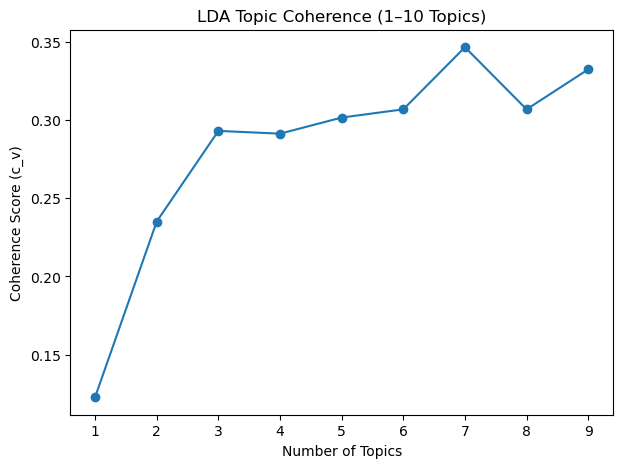

In [24]:
plt.figure(figsize=(7,5))
plt.plot(range(1,10), coherence_scores, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("LDA Topic Coherence (1–10 Topics)")
plt.show()

#### Author Topic Model (Structural Topic Model)

Like LDA but STM provides two ways to include contextual information:

1) Topic prevalence
2) Topic content

Certain judges might talk about a certain issue more (prevalence), or more enthusiastically (content)

In [25]:
from gensim.models import AuthorTopicModel
from gensim.test.utils import temporary_file

df = df.reset_index()
df['id'] = df.index
author2doc = df[:100][['authorship','id']]
author2doc = author2doc.groupby('authorship').apply(lambda x: list(x['id'])).to_dict()

model = AuthorTopicModel(
        doc_term_matrix, author2doc=author2doc, id2word=dictionary, num_topics=10)

# For each author list topic distribution
author_vecs = [model.get_author_topics(author) for author in model.id2author.values()]
author_vecs[:2]

[[(1, np.float64(0.3889598376806702)),
  (4, np.float64(0.06168736096192167)),
  (5, np.float64(0.39225739544581606)),
  (9, np.float64(0.15687990177121847))],
 [(0, np.float64(0.10458446273831502)),
  (1, np.float64(0.09943543536199087)),
  (3, np.float64(0.15830487598083617)),
  (8, np.float64(0.6375681469667247))]]

In [26]:
import pandas as pd

# Get full distribution for each author (minimum_probability=0 forces all topics)
author_names = list(model.id2author.values())

rows = {}
for author in author_names:
    topic_dist = dict(model.get_author_topics(author, minimum_probability=0))
    rows[author] = [topic_dist.get(i, 0.0) for i in range(model.num_topics)]

author_topic_df = pd.DataFrame(rows, index=[f"Topic {i}" for i in range(model.num_topics)]).T
author_topic_df


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9
ALITO,0.000036,0.388960,0.000036,0.000036,0.061687,0.392257,0.000036,0.000036,0.000036,0.156880
BREYER,0.104584,0.099435,0.000018,0.158305,0.000018,0.000018,0.000018,0.000018,0.637568,0.000018
GINSBURG,0.000019,0.203506,0.051442,0.000019,0.672476,0.000019,0.000019,0.000019,0.043343,0.029137
KENNEDY,0.081376,0.000026,0.000026,0.776927,0.000026,0.000407,0.043577,0.000026,0.000026,0.097584
O'CONNOR,0.000026,0.000026,0.000026,0.196268,0.430914,0.000026,0.055630,0.042767,0.274292,0.000026
REHNQUIST,0.000067,0.223038,0.000067,0.327896,0.216634,0.000067,0.192233,0.000067,0.039862,0.000067
ROBERTS,0.166284,0.154725,0.011947,0.008620,0.626322,0.003974,0.000056,0.000057,0.022356,0.005657
SCALIA,0.048454,0.000008,0.116692,0.000008,0.490098,0.000008,0.000008,0.000008,0.341840,0.002874
SOUTER,0.324941,0.000035,0.000035,0.000035,0.247760,0.140578,0.000035,0.286511,0.000035,0.000035
STEVENS,0.000039,0.032298,0.120793,0.055547,0.128656,0.000039,0.000039,0.000039,0.042950,0.619603


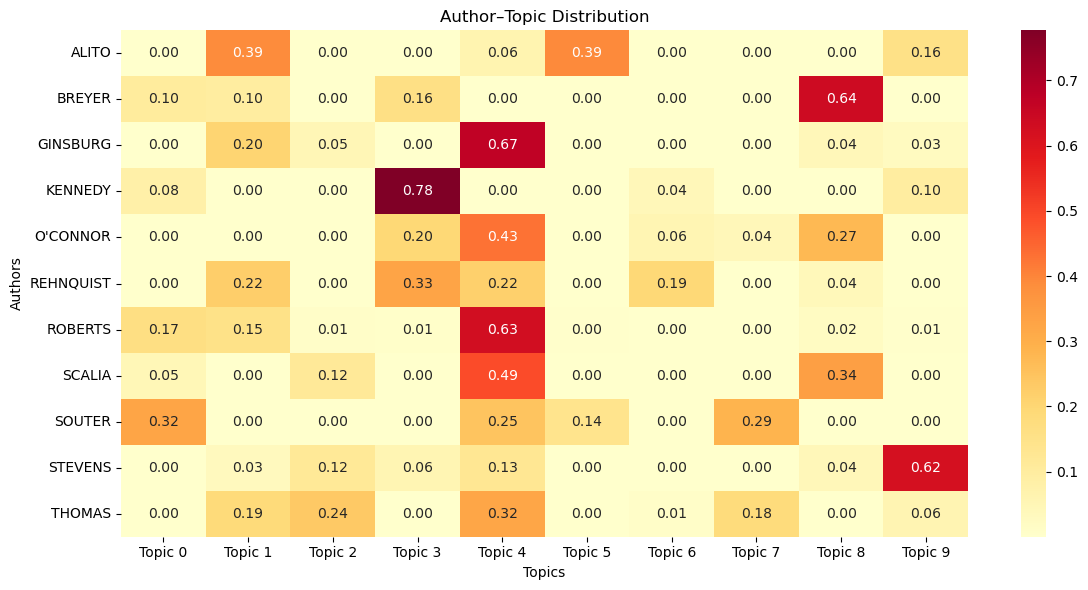

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(author_topic_df, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Author–Topic Distribution")
plt.xlabel("Topics")
plt.ylabel("Authors")
plt.tight_layout()
plt.show()
